# Hand Written Digits Project

**Data reference link:**

1. [TÜBİTAK Article](https://journals.tubitak.gov.tr/cgi/viewcontent.cgi?article=3717&context=elektrik)
2. [UCI Machine Learning Repository: Pen-Based Recognition of Handwritten Digits Dataset](https://archive.ics.uci.edu/dataset/81/pen+based+recognition+of+handwritten+digits)

- This is a dataset used to recognize handwritten digits.

- The dataset contains scanned images of handwritten digits.

- The dataset has a total of 10 classes, with each class representing a digit between 0 and 9.

- Data from 44 subjects, with 250 samples each, has been collected.

- The dataset includes information about which digit each image represents, in addition to the image data.

- This dataset is often used to evaluate the performance of machine learning algorithms in handwriting recognition.

- It is also a popular dataset used in the training of deep learning models.

**Pen-Based Recognition of Handwritten Digits**

- We are creating a digit database by collecting 250 samples from a total of 44 writers. Samples written by 30 writers are used for training, cross-validation, and author-dependent testing, while samples from the remaining 14 writers are used for author-independent testing. This database is also available in UNIPEN format.

- We use a WACOM PL-100V pressure-sensitive tablet with an integrated LCD screen and a wireless pen. The input and display areas are located in the same place. This tablet, connected to the serial port of an Intel 486-based computer, allows us to collect handwriting samples. The tablet sends $x$ and $y$ tablet coordinates and pen pressure level values at fixed time intervals of 100 milliseconds (sampling rate).

- These writers are asked to write 250 digits in random order in boxes with a resolution of 500 by 500 tablet pixels. The subject is only monitored during the first input screens. Each screen contains five boxes displaying the digits to be written. Subjects are instructed to write only within these boxes. If they make a mistake or are unsatisfied with their writing, they are instructed to clear the contents of a box using a button on the screen. Since most writers are unfamiliar with such input devices, the first ten digits are ignored, although subjects are unaware of this.

- In our study, we only use ($x, y$) coordinate data. Pen pressure level values are ignored. First, we apply normalization to make our representation invariant to translations and scale distortions. The raw data from the tablet consists of integer values between 0 and 500 (tablet input box resolution). The new coordinates are adjusted so that the coordinate with the maximum range varies between 0 and 100. Since most characters are taller than they are wide, $x$ generally remains within this range.

**Breakdown of values**
The **Pen-Digit Dataset** is a collection of data that shows how people write numbers (0 to 9) using a special tablet that can track the pen's movements.

- When someone writes a number on this tablet, the **X** and **Y** values show where the pen is on the tablet.
- **X** is like the **left-to-right** position of the pen.
- **Y** is like the **up-and-down** position of the pen.

Imagine you’re writing the number “2” on a piece of paper. As you move your pen, the tablet records **8 different points** of the pen’s movement. Each point has an X value (how far left or right the pen is) and a Y value (how far up or down the pen is).

For example:
- X1, Y1 could be where you start writing “2.”
- X2, Y2 could be the next point as you curve the pen.
- And so on, until X8, Y8, which is near the end of writing the “2.”

These numbers (X and Y coordinates) help computers understand the shape of the digit you're writing.

### Simple Example:
- You start writing “2” at the top left corner of the tablet (X1 = 10, Y1 = 80).
- You move down a bit (X2 = 12, Y2 = 60).
- You curve around (X3 = 30, Y3 = 40), and so on.

The computer uses these points to figure out: "Oh, this looks like a '2'!"

### In summary:
- The **X and Y** values are just locations showing where the pen moved while writing a number.
- The computer learns from these locations to recognize the digit.

# Exploratory Data Analysis

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#%matplotlib inline
#%matplotlib notebook

plt.rcParams["figure.figsize"] = (10,6)
import warnings
warnings.filterwarnings("ignore")
warnings.warn("this will not show")
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [2]:
df = pd.read_csv("pendigits_txt.csv")

In [3]:
df.head()

,input1,input2,input3,input4,input5,input6,input7,input8,input9,input10,input11,input12,input13,input14,input15,input16,class
0,47,100,27,81,57,37,26,0,0,23,56,53,100,90,40,98,8
1,0,89,27,100,42,75,29,45,15,15,37,0,69,2,100,6,2
2,0,57,31,68,72,90,100,100,76,75,50,51,28,25,16,0,1
3,0,100,7,92,5,68,19,45,86,34,100,45,74,23,67,0,4
4,0,67,49,83,100,100,81,80,60,60,40,40,33,20,47,0,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10992 entries, 0 to 10991
Data columns (total 17 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   input1   10992 non-null  int64
 1   input2   10992 non-null  int64
 2   input3   10992 non-null  int64
 3   input4   10992 non-null  int64
 4   input5   10992 non-null  int64
 5   input6   10992 non-null  int64
 6   input7   10992 non-null  int64
 7   input8   10992 non-null  int64
 8   input9   10992 non-null  int64
 9   input10  10992 non-null  int64
 10  input11  10992 non-null  int64
 11  input12  10992 non-null  int64
 12  input13  10992 non-null  int64
 13  input14  10992 non-null  int64
 14  input15  10992 non-null  int64
 15  input16  10992 non-null  int64
 16  class    10992 non-null  int64
dtypes: int64(17)
memory usage: 1.4 MB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
input1,10992.000,38.814,34.258,0.000,6.000,32.000,65.000,100.000
input2,10992.000,85.120,16.219,0.000,76.000,89.000,100.000,100.000
input3,10992.000,40.606,26.343,0.000,20.000,40.000,58.000,100.000
input4,10992.000,83.774,19.164,0.000,72.000,91.000,100.000,100.000
input5,10992.000,49.770,34.101,0.000,18.000,53.000,78.000,100.000
input6,10992.000,65.573,26.997,0.000,49.000,71.000,86.000,100.000
input7,10992.000,51.220,30.577,0.000,28.000,53.500,74.000,100.000
input8,10992.000,44.499,29.906,0.000,23.000,43.000,64.000,100.000
input9,10992.000,56.869,34.136,0.000,29.000,60.000,89.000,100.000
input10,10992.000,33.696,27.252,0.000,7.000,33.000,54.000,100.000


In [6]:
df.isnull().sum()

input1     0
input2     0
input3     0
input4     0
input5     0
input6     0
input7     0
input8     0
input9     0
input10    0
input11    0
input12    0
input13    0
input14    0
input15    0
input16    0
class      0
dtype: int64

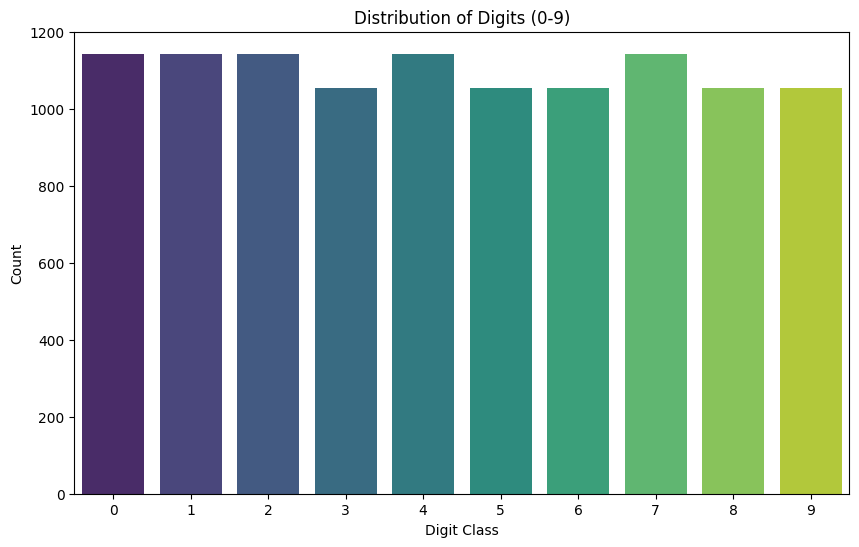

In [7]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='class', palette='viridis')
plt.title('Distribution of Digits (0-9)')
plt.xlabel('Digit Class')
plt.ylabel('Count')
plt.show()

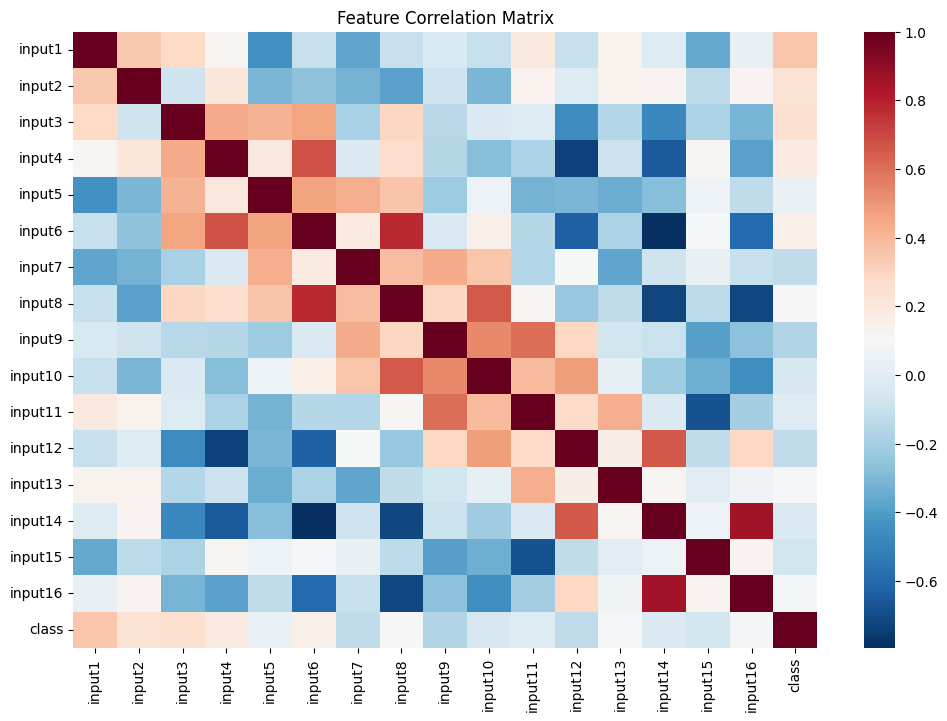

In [8]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=False, cmap='RdBu_r')
plt.title('Feature Correlation Matrix')
plt.show()

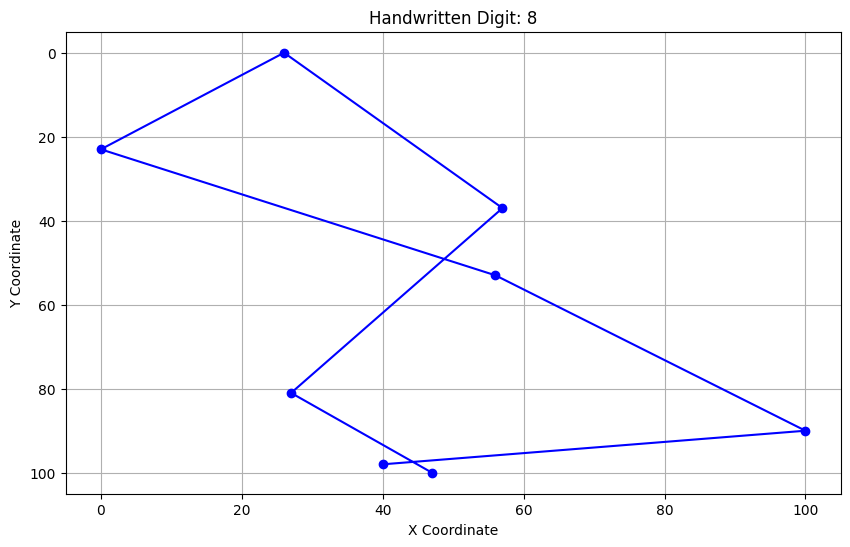

In [9]:
def plot_digit(row_index):
    row = df.iloc[row_index]
    x_coords = [row[f'input{i}'] for i in range(1, 17, 2)]
    y_coords = [row[f'input{i}'] for i in range(2, 17, 2)]
    
    plt.plot(x_coords, y_coords, marker='o', linestyle='-', color='blue')
    plt.title(f"Handwritten Digit: {row['class']}")
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.gca().invert_yaxis() 
    plt.grid(True)
    plt.show()

plot_digit(0)

# Support Vector Machine (SVM) Classifier

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [11]:
X = df.drop('class', axis=1)
y = df['class']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Modeling 

In [14]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

In [15]:
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_model.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [16]:
y_pred_svm = svm_model.predict(X_test_scaled)

In [17]:
accuracy = accuracy_score(y_test, y_pred_svm)
print(f"SVM Model Accuracy: {accuracy:.4f}")

SVM Model Accuracy: 0.9945


In [18]:
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_svm))


--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       241
           1       1.00      0.99      0.99       225
           2       0.99      1.00      1.00       235
           3       1.00      1.00      1.00       224
           4       1.00      1.00      1.00       215
           5       1.00      0.99      0.99       213
           6       1.00      1.00      1.00       199
           7       0.98      1.00      0.99       209
           8       0.99      1.00      0.99       212
           9       1.00      0.99      0.99       226

    accuracy                           0.99      2199
   macro avg       0.99      0.99      0.99      2199
weighted avg       0.99      0.99      0.99      2199



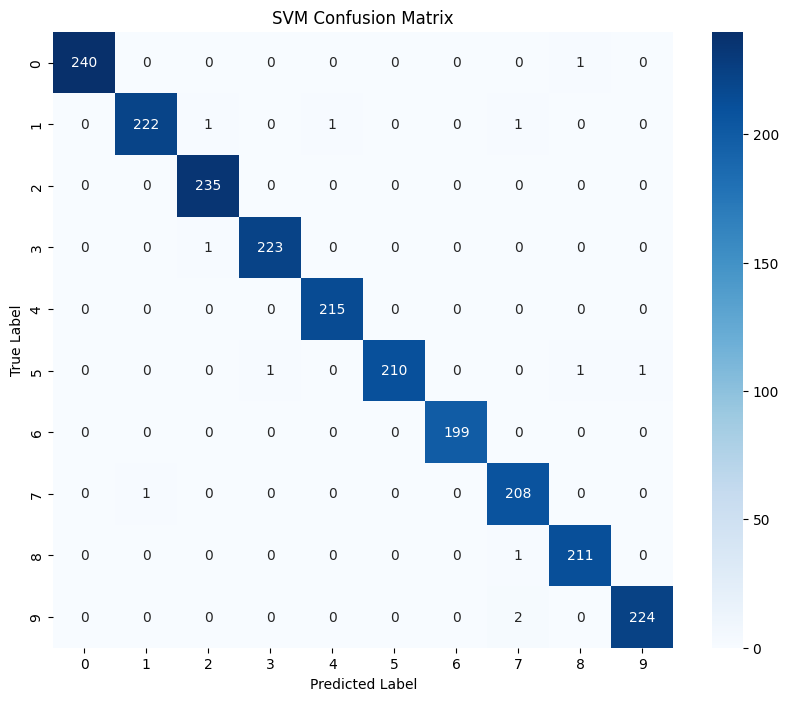

In [19]:
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Blues')
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Decision Tree (DT) Classifier

In [20]:
from sklearn.tree import DecisionTreeClassifier

In [21]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [22]:
y_pred_dt = dt_model.predict(X_test_scaled)

In [23]:
print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9654

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       241
           1       0.94      0.93      0.94       225
           2       0.95      0.97      0.96       235
           3       0.97      0.97      0.97       224
           4       0.99      0.97      0.98       215
           5       0.96      0.97      0.97       213
           6       0.98      0.97      0.98       199
           7       0.96      0.96      0.96       209
           8       0.95      0.98      0.97       212
           9       0.97      0.95      0.96       226

    accuracy                           0.97      2199
   macro avg       0.97      0.97      0.97      2199
weighted avg       0.97      0.97      0.97      2199



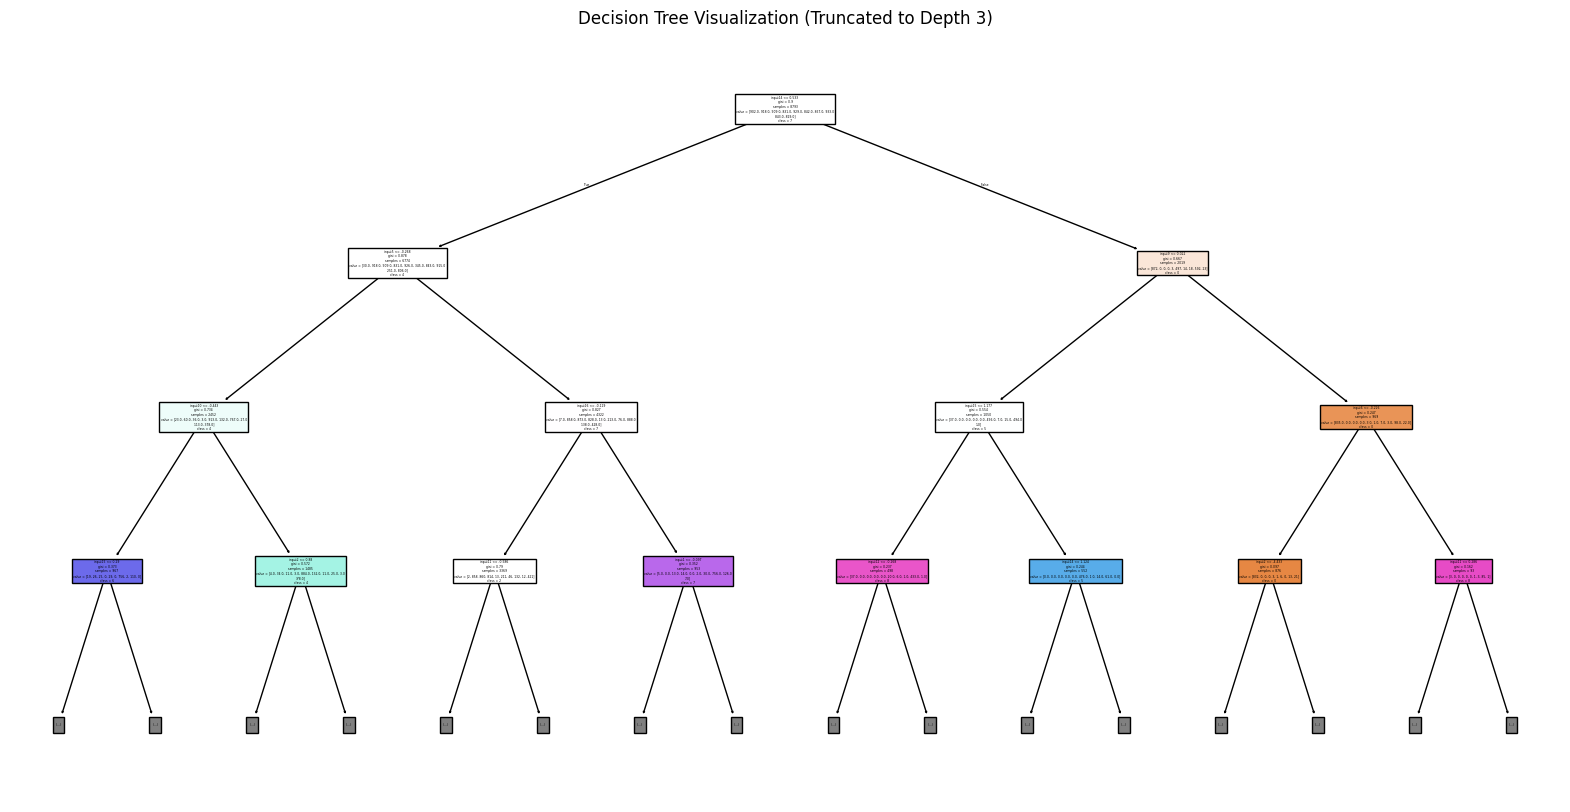

In [24]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(dt_model, filled=True, feature_names=X.columns, class_names=[str(i) for i in range(10)], max_depth=3)
plt.title("Decision Tree Visualization (Truncated to Depth 3)")
plt.show()

# Random Forest Classifier

In [25]:
from sklearn.ensemble import RandomForestClassifier

In [26]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
y_pred_rf = rf_model.predict(X_test_scaled)

In [28]:
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9936

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       241
           1       1.00      0.98      0.99       225
           2       0.99      1.00      0.99       235
           3       1.00      0.99      0.99       224
           4       0.99      1.00      1.00       215
           5       1.00      0.99      0.99       213
           6       1.00      1.00      1.00       199
           7       0.99      1.00      0.99       209
           8       0.99      1.00      0.99       212
           9       1.00      0.99      0.99       226

    accuracy                           0.99      2199
   macro avg       0.99      0.99      0.99      2199
weighted avg       0.99      0.99      0.99      2199



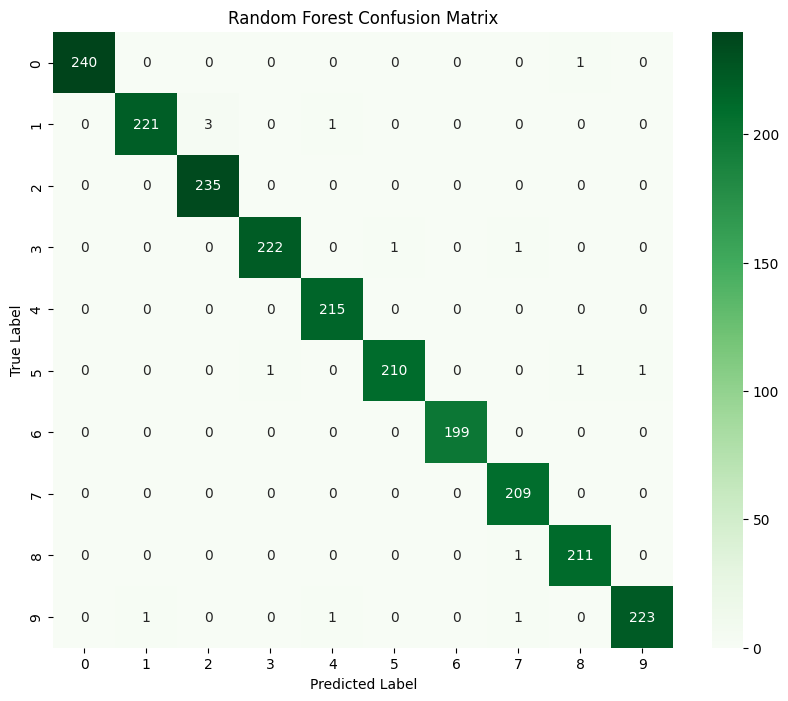

In [29]:
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Cross Validation

In [30]:
from sklearn.model_selection import cross_val_score

In [31]:
models = {
    "SVM": SVC(kernel='rbf'),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

In [32]:
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    print(f"{name} Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

SVM Mean CV Accuracy: 0.9949 (+/- 0.0024)
Decision Tree Mean CV Accuracy: 0.9592 (+/- 0.0114)
Random Forest Mean CV Accuracy: 0.9904 (+/- 0.0050)


# Grid Search

In [33]:
from sklearn.model_selection import GridSearchCV

In [34]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 0.01],
    'kernel': ['rbf']
}

In [35]:
grid_svm = GridSearchCV(SVC(), param_grid, cv=5, verbose=1, n_jobs=-1)
grid_svm.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto', ...], 'kernel': ['rbf']}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


In [36]:
print(f"Best SVM Parameters: {grid_svm.best_params_}")
best_svm_model = grid_svm.best_estimator_

Best SVM Parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}


In [37]:
dt_param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [38]:
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), 
                       dt_param_grid, 
                       cv=5, 
                       n_jobs=-1, 
                       verbose=1)
grid_dt.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [39]:
print(f"Best Decision Tree Parameters: {grid_dt.best_params_}")
best_dt_model = grid_dt.best_estimator_

Best Decision Tree Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [40]:
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

In [41]:
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), 
                       rf_param_grid, 
                       cv=5, 
                       n_jobs=-1, 
                       verbose=1)
grid_rf.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'bootstrap': [True, False], 'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'n_estimators': [100, 200, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


In [42]:
print(f"Best Random Forest Parameters: {grid_rf.best_params_}")
best_rf_model = grid_rf.best_estimator_

Best Random Forest Parameters: {'bootstrap': False, 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 300}


# Choose the Best Model

In [43]:
y_pred_svm_opt = grid_svm.predict(X_test_scaled)
y_pred_dt_opt = best_dt_model.predict(X_test_scaled)
y_pred_rf_opt = best_rf_model.predict(X_test_scaled)

In [44]:
comparison_data = {
    'Model': ['SVM (Optimized)', 'Decision Tree (Optimized)', 'Random Forest (Optimized)'],
    'Accuracy': [accuracy_score(y_test, y_pred_svm_opt),
                 accuracy_score(y_test, y_pred_dt_opt),
                 accuracy_score(y_test, y_pred_rf_opt)],
    'F1 Score (Macro)': [f1_score(y_test, y_pred_svm_opt, average='macro'),
                         f1_score(y_test, y_pred_dt_opt, average='macro'),
                         f1_score(y_test, y_pred_rf_opt, average='macro')]
}

In [45]:
df_final_compare = pd.DataFrame(comparison_data).sort_values(by='Accuracy', ascending=False)
display(df_final_compare)

,Model,Accuracy,F1 Score (Macro)
0,SVM (Optimized),0.996,0.996
2,Random Forest (Optimized),0.994,0.994
1,Decision Tree (Optimized),0.961,0.961


In [46]:
best_model_name = df_final_compare.iloc[0]['Model']
best_model_accuracy = df_final_compare.iloc[0]['Accuracy']

print(f"The best performing model is: {best_model_name} with an accuracy of {best_model_accuracy:.4f}")

The best performing model is: SVM (Optimized) with an accuracy of 0.9959


## CONCLUSION
The achieved score of 0.9959 demonstrates that SVM possesses a superior generalization capability compared to models like Decision Tree or Random Forest for this type of coordinate-based dataset. This geometric approach, which maximizes the margin between classes, minimizes the error rate despite variations in different individuals' writing styles, offering the most reliable solution for pen-based recognition systems. 